Saving POWER_Point_Daily_20240101_20250101_034d35N_047d07E_LST.csv to POWER_Point_Daily_20240101_20250101_034d35N_047d07E_LST (19).csv
Loaded file: POWER_Point_Daily_20240101_20250101_034d35N_047d07E_LST (19).csv


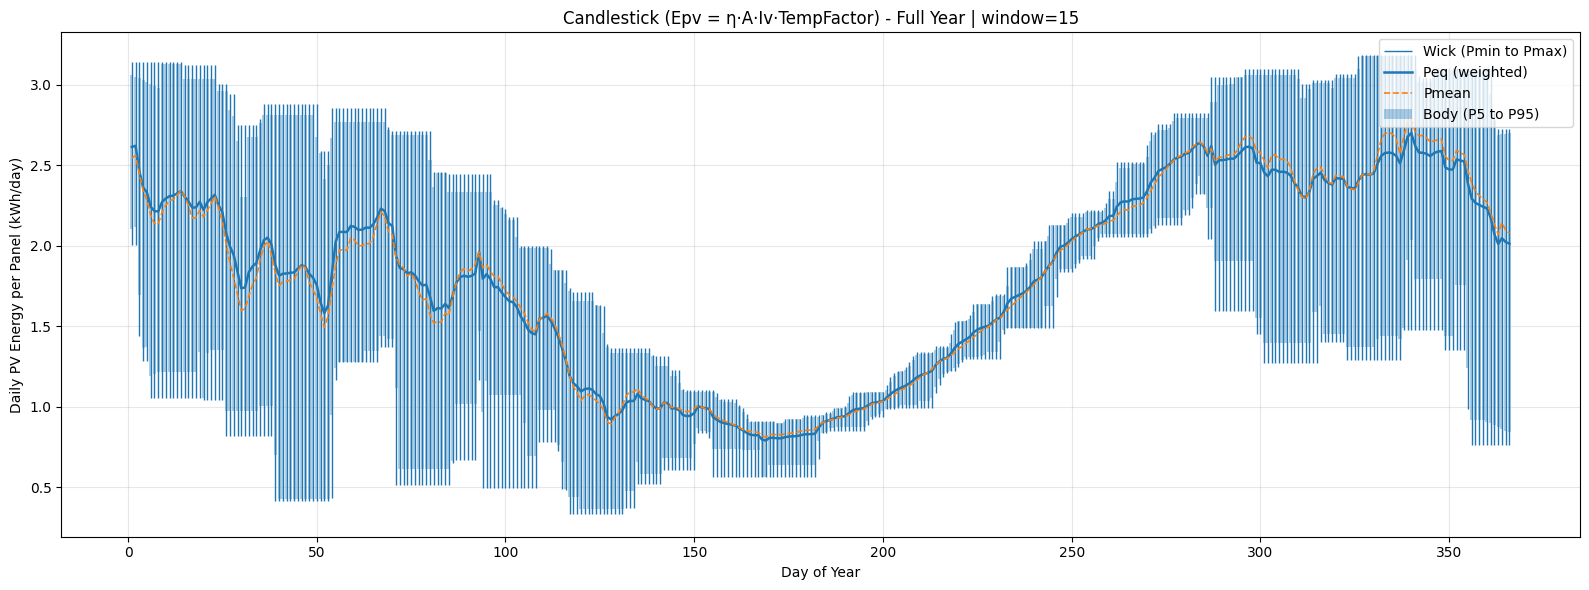

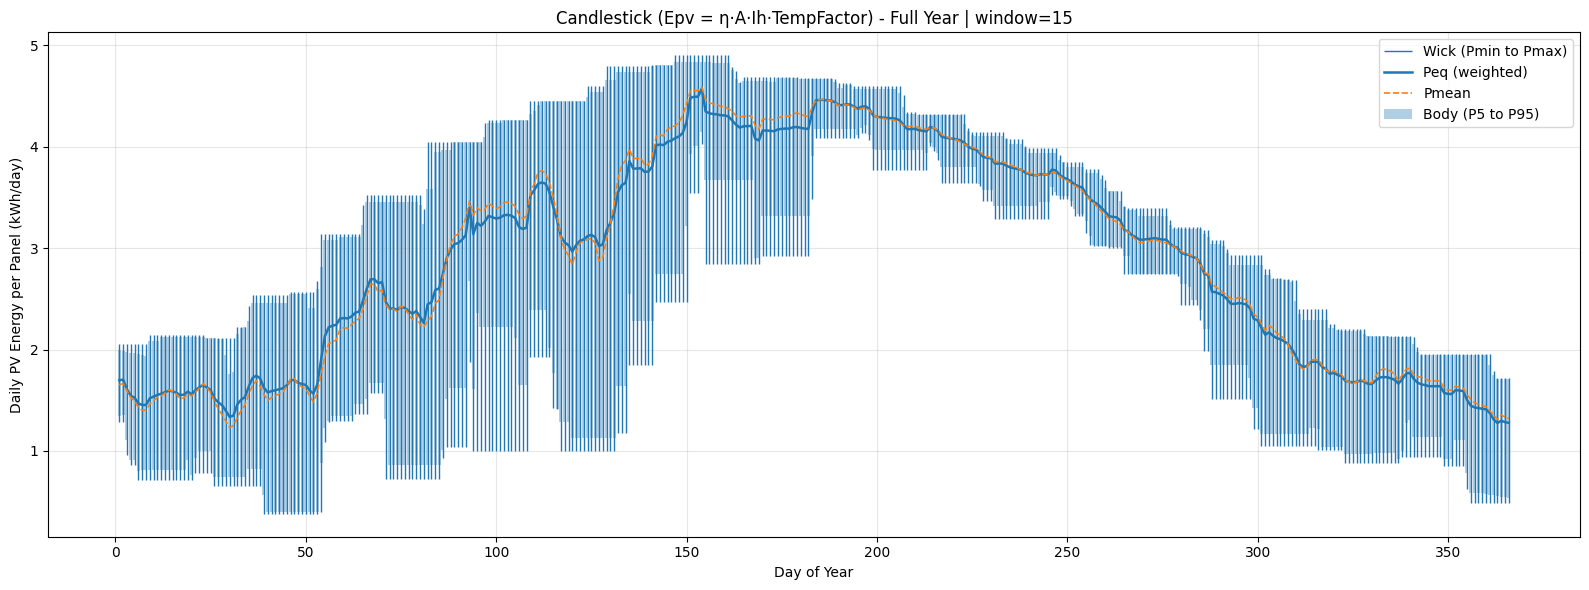

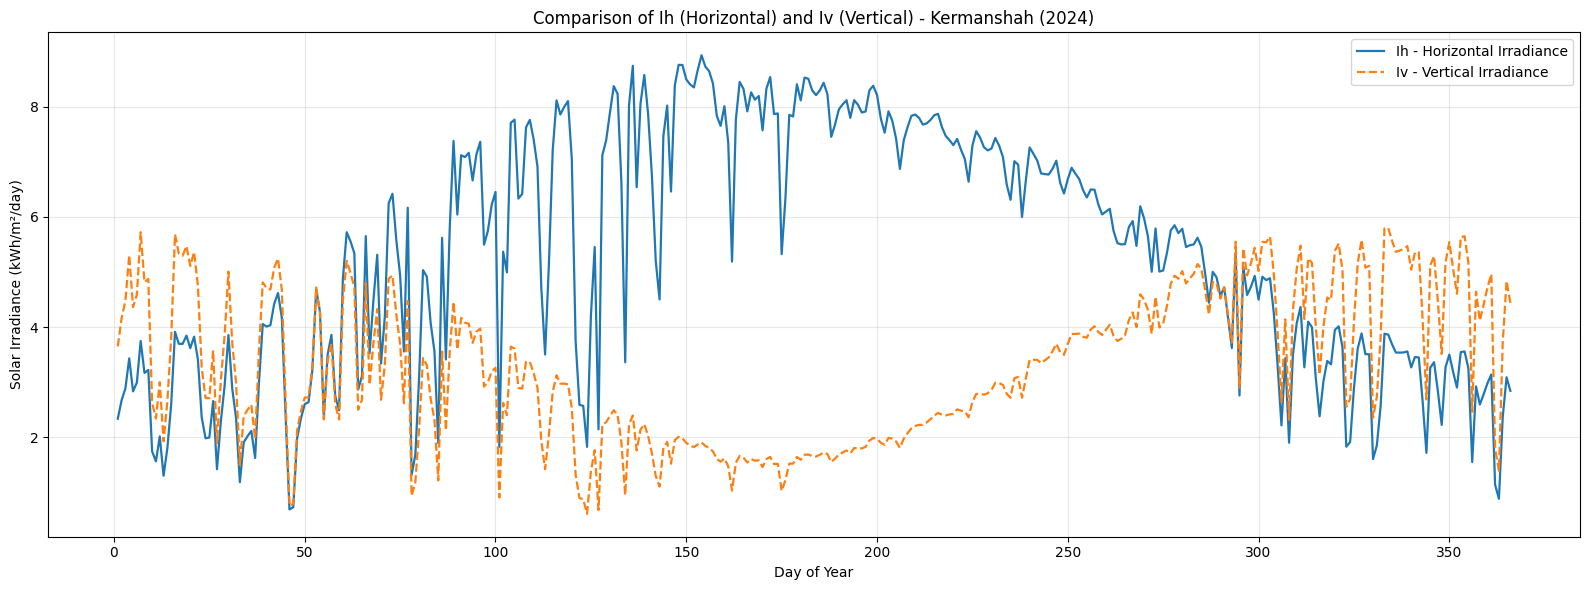

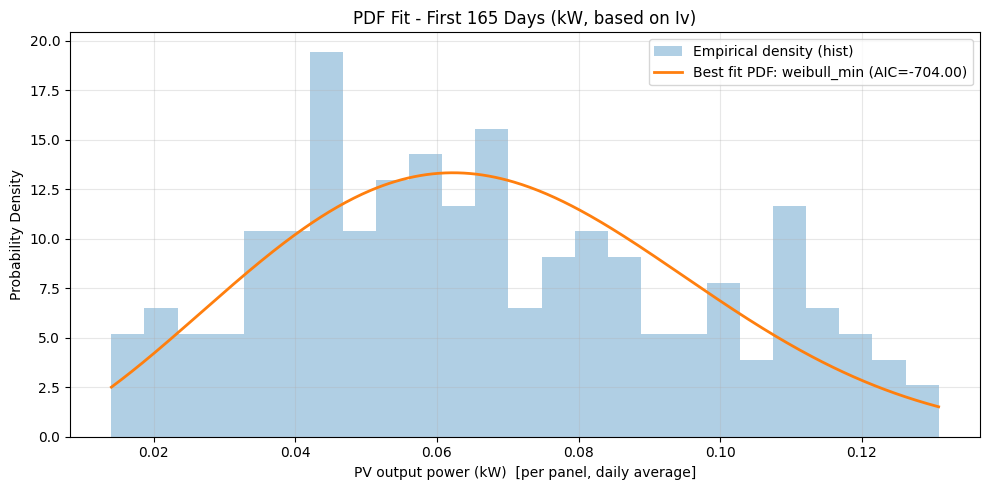


--- PDF Fit - First 165 Days (kW, based on Iv) ---
Best distribution: weibull_min
Best params: (np.float64(2.516091200288868), 0, np.float64(0.07615091030490487))
AIC: -704.0023123197391
All candidates (sorted by AIC):
  weibull_min   AIC=-704.00  params=(np.float64(2.516091200288868), 0, np.float64(0.07615091030490487))
  gamma         AIC=-700.15  params=(4.851511998759144, 0, np.float64(0.0138967426615748))
  lognorm       AIC=-688.23  params=(np.float64(0.48711108224412736), 0, np.float64(0.0606038533300677))


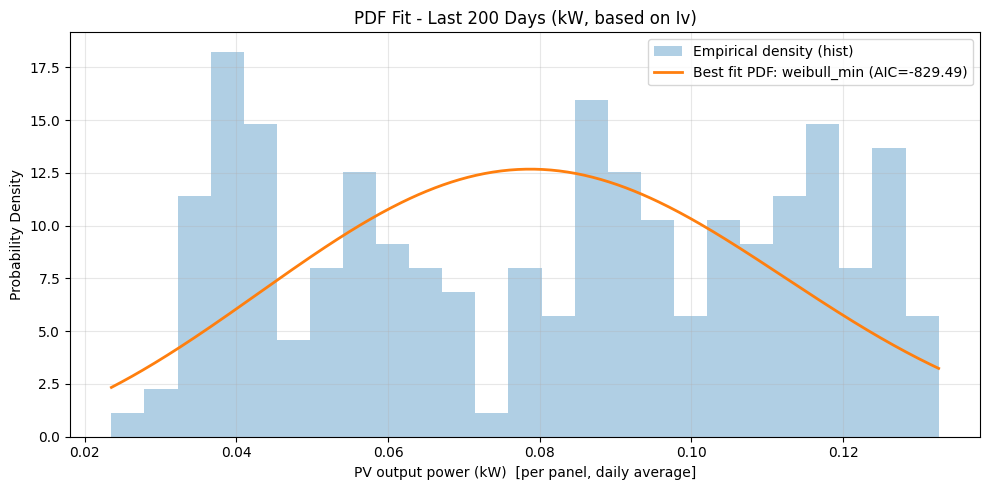


--- PDF Fit - Last 200 Days (kW, based on Iv) ---
Best distribution: weibull_min
Best params: (np.float64(2.92825069096892), 0, np.float64(0.09082567780528637))
AIC: -829.4906334069549
All candidates (sorted by AIC):
  weibull_min   AIC=-829.49  params=(np.float64(2.92825069096892), 0, np.float64(0.09082567780528637))
  gamma         AIC=-817.10  params=(5.939783524430902, 0, np.float64(0.013585483984124567))
  lognorm       AIC=-805.40  params=(np.float64(0.43442392338726044), 0, np.float64(0.07400561920851487))


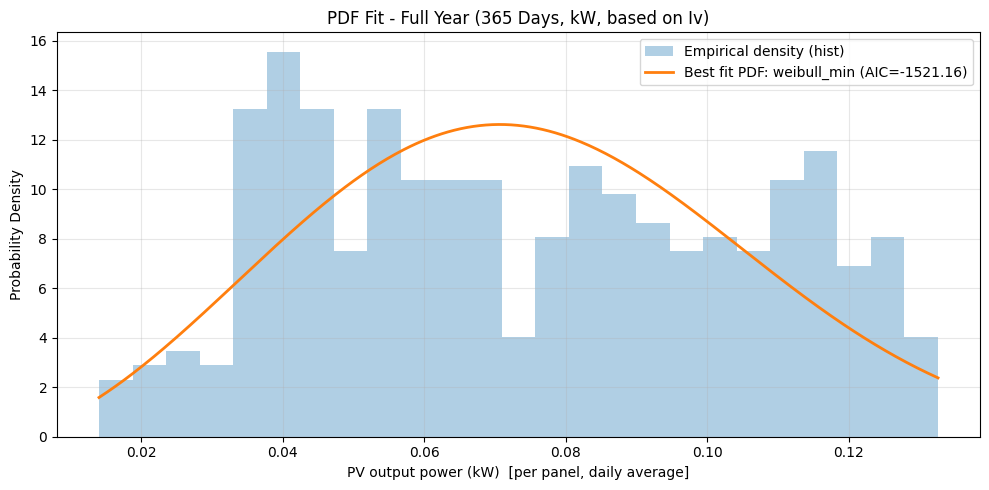


--- PDF Fit - Full Year (365 Days, kW, based on Iv) ---
Best distribution: weibull_min
Best params: (np.float64(2.663623936349806), 0, np.float64(0.08430915935755975))
AIC: -1521.1614210327477
All candidates (sorted by AIC):
  weibull_min   AIC=-1521.16  params=(np.float64(2.663623936349806), 0, np.float64(0.08430915935755975))
  gamma         AIC=-1505.90  params=(5.183815449192248, 0, np.float64(0.014412236461358814))
  lognorm       AIC=-1480.46  params=(np.float64(0.4695684711312373), 0, np.float64(0.067631586016605))


In [23]:

from google.colab import files
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

uploaded = files.upload()

csv_name = None
for name in uploaded.keys():
    if name.lower().endswith(".csv"):
        csv_name = name
        break

if csv_name is None:
    raise ValueError("هیچ فایل CSV پیدا نشد. لطفاً فایل CSV ناسا را آپلود کنید.")

print("Loaded file:", csv_name)

df = pd.read_csv(io.BytesIO(uploaded[csv_name]), skiprows=13)


df["date"] = pd.to_datetime(df[["YEAR", "MO", "DY"]].rename(columns={"YEAR":"year","MO":"month","DY":"day"}))
df = df.sort_values("date").reset_index(drop=True)

df_2024 = df[(df["date"] >= "2024-01-01") & (df["date"] <= "2024-12-31")].copy()
df_2024["doy"] = df_2024["date"].dt.dayofyear

Ih = df_2024["ALLSKY_SFC_SW_DWN"].astype(float).values

lat_deg = 34.3543
phi = np.deg2rad(lat_deg)

n = df_2024["doy"].values
delta = np.deg2rad(23.45) * np.sin(np.deg2rad(360.0*(284 + n)/365.0))

cos_tz = np.cos(phi - delta)
cos_ti = np.sin(phi - delta)
ratio = np.where((cos_tz > 1e-6) & (cos_ti > 0), cos_ti / cos_tz, 0.0)
Iv = Ih * ratio


# Trina Solar Vertex 550W

eta_pv = 0.21
A_pv  = 2.614
T_out = 25.0
temp_factor = (1 - 0.005*(T_out - 25))


E_pv_v = eta_pv * A_pv * Iv * temp_factor
E_pv_h = eta_pv * A_pv * Ih * temp_factor

df_2024["E_pv_v_kWh_day"] = E_pv_v
df_2024["E_pv_h_kWh_day"] = E_pv_h

df_2024["P_pv_v_kW_avg"] = df_2024["E_pv_v_kWh_day"] / 24.0
df_2024["P_pv_h_kW_avg"] = df_2024["E_pv_h_kWh_day"] / 24.0


def build_candle_columns(df_in, series_col, window=15,
                         wmin=0.10, w_p5=0.10, w_mean=0.50, w_p95=0.15, wmax=0.15):
    df = df_in.copy()
    series = df[series_col].astype(float).values

    Pmin  = np.full_like(series, np.nan, dtype=float)
    P5    = np.full_like(series, np.nan, dtype=float)
    Pmean = np.full_like(series, np.nan, dtype=float)
    P95   = np.full_like(series, np.nan, dtype=float)
    Pmax  = np.full_like(series, np.nan, dtype=float)

    half = window // 2
    for i in range(len(series)):
        lo = max(0, i-half)
        hi = min(len(series), i+half+1)
        w = series[lo:hi]
        w = w[np.isfinite(w)]
        w = w[w > 0]
        if len(w) == 0:
            continue
        Pmin[i]  = np.min(w)
        P5[i]    = np.percentile(w, 5)
        Pmean[i] = np.mean(w)
        P95[i]   = np.percentile(w, 95)
        Pmax[i]  = np.max(w)

    df["Pmin"] = Pmin
    df["P5"] = P5
    df["Pmean"] = Pmean
    df["P95"] = P95
    df["Pmax"] = Pmax

    df["Peq"] = (wmin*df["Pmin"] + w_p5*df["P5"] + w_mean*df["Pmean"] +
                 w_p95*df["P95"] + wmax*df["Pmax"])
    return df


def plot_candlestick(df, title):
    x = df["doy"].values
    pmin = df["Pmin"].values
    p5   = df["P5"].values
    p95  = df["P95"].values
    pmax = df["Pmax"].values
    peq  = df["Peq"].values
    pmean = df["Pmean"].values

    plt.figure(figsize=(16,6))
    plt.vlines(x, pmin, pmax, linewidth=1, label="Wick (Pmin to Pmax)")
    plt.bar(x, p95-p5, bottom=p5, width=0.8, alpha=0.35, label="Body (P5 to P95)")
    plt.plot(x, peq, linewidth=1.8, label="Peq (weighted)")
    plt.plot(x, pmean, linewidth=1.2, linestyle="--", label="Pmean")
    plt.xlabel("Day of Year")
    plt.ylabel("Daily PV Energy per Panel (kWh/day)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()


window = 15

df_v = build_candle_columns(df_2024, "E_pv_v_kWh_day", window=window)
plot_candlestick(df_v, f"Candlestick (Epv = η·A·Iv·TempFactor) - Full Year | window={window}")

df_h = build_candle_columns(df_2024, "E_pv_h_kWh_day", window=window)
plot_candlestick(df_h, f"Candlestick (Epv = η·A·Ih·TempFactor) - Full Year | window={window}")


plt.figure(figsize=(16,6))
plt.plot(df_2024["doy"], Ih, linewidth=1.6, label="Ih - Horizontal Irradiance")
plt.plot(df_2024["doy"], Iv, linewidth=1.6, linestyle="--", label="Iv - Vertical Irradiance")
plt.xlabel("Day of Year")
plt.ylabel("Solar Irradiance (kWh/m²/day)")
plt.title("Comparison of Ih (Horizontal) and Iv (Vertical) - Kermanshah (2024)")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True, loc="upper right")
plt.tight_layout()
plt.show()


df_165 = df_2024[df_2024["doy"] <= 165].copy()
df_200 = df_2024[df_2024["doy"] > 165].copy()

def fit_dist_and_aic(dist, data):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]
    if len(data) < 20:
        return None

    params = dist.fit(data, floc=0)
    ll = np.sum(dist.logpdf(data, *params))
    k = len(params)
    aic = 2*k - 2*ll
    return {"dist": dist, "params": params, "aic": aic}

def choose_best_distribution(data):
    dists = [stats.gamma, stats.lognorm, stats.weibull_min]
    candidates = []
    for dist in dists:
        out = fit_dist_and_aic(dist, data)
        if out is not None:
            candidates.append(out)
    if not candidates:
        raise ValueError("داده کافی/معتبر برای فیت توزیع وجود ندارد.")
    best = min(candidates, key=lambda x: x["aic"])
    return best, sorted(candidates, key=lambda x: x["aic"])

def plot_density_with_best_fit(data, title, bins=25):
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    data = data[data > 0]

    best, candidates = choose_best_distribution(data)
    x = np.linspace(np.min(data), np.max(data), 400)

    dist = best["dist"]
    params = best["params"]
    pdf = dist.pdf(x, *params)

    plt.figure(figsize=(10,5))
    plt.hist(data, bins=bins, density=True, alpha=0.35, label="Empirical density (hist)")
    plt.plot(x, pdf, linewidth=2.0, label=f"Best fit PDF: {dist.name} (AIC={best['aic']:.2f})")
    plt.xlabel("PV output power (kW)  [per panel, daily average]")
    plt.ylabel("Probability Density")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()

    print("\n---", title, "---")
    print("Best distribution:", dist.name)
    print("Best params:", params)
    print("AIC:", best["aic"])
    print("All candidates (sorted by AIC):")
    for c in candidates:
        print(f"  {c['dist'].name:12s}  AIC={c['aic']:.2f}  params={c['params']}")

plot_density_with_best_fit(df_165["P_pv_v_kW_avg"].values, "PDF Fit - First 165 Days (kW, based on Iv)")
plot_density_with_best_fit(df_200["P_pv_v_kW_avg"].values, "PDF Fit - Last 200 Days (kW, based on Iv)")
plot_density_with_best_fit(df_2024["P_pv_v_kW_avg"].values, "PDF Fit - Full Year (365 Days, kW, based on Iv)")
